# 1. Data Loading and Inspection

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df = pd.read_csv('q1_heart_disease.csv')
df.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [72]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int64  
 1   sex              800 non-null    int64  
 2   chest_pain_type  800 non-null    object 
 3   resting_bp       776 non-null    float64
 4   cholesterol      768 non-null    float64
 5   fasting_bs       800 non-null    int64  
 6   resting_ecg      800 non-null    object 
 7   max_hr           800 non-null    int64  
 8   exercise_angina  800 non-null    int64  
 9   oldpeak          800 non-null    float64
 10  st_slope         800 non-null    object 
 11  heart_disease    800 non-null    int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 75.1+ KB


,0
age,0
sex,0
chest_pain_type,0
resting_bp,24
cholesterol,32
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


### Observations


*   The dataset contains 800 rows and 12 columns.

*   Missing values are present in resting_bp (24) and cholesterol (32).


*   The dataset has both numerical and categorical features such as age, max_hr, chest_pain_type, and resting_ecg.
*   The target variable heart_disease is binary (0 = No disease, 1 = Disease).









# 2. Exploratory Data Analysis

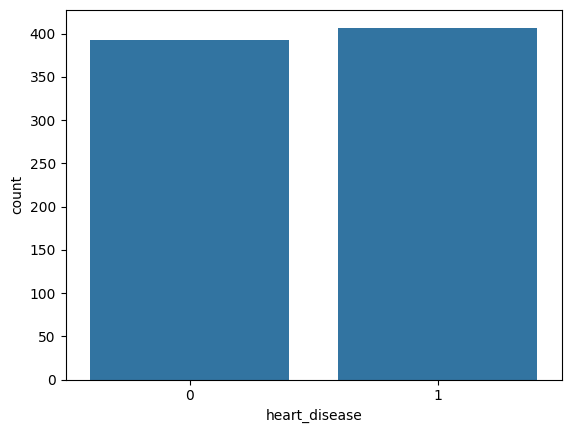

In [73]:
sns.countplot(x='heart_disease', data=df)
plt.show()

The target variable (heart_disease) is almost balanced, with similar counts for both classes.
This indicates no major class imbalance in the dataset.

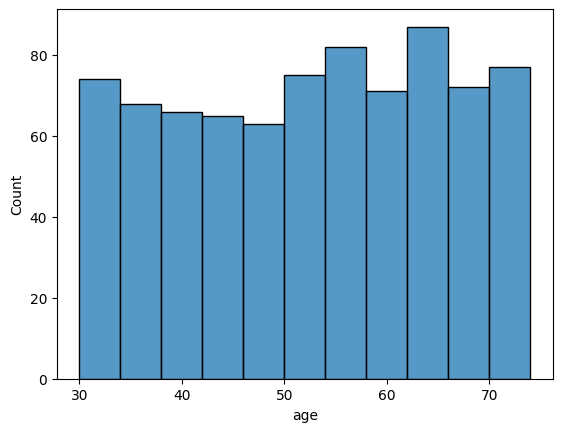

In [74]:
sns.histplot(df['age'])
plt.show()

The target variable (heart_disease) is almost balanced, with similar counts for both classes.
This indicates no major class imbalance in the dataset.

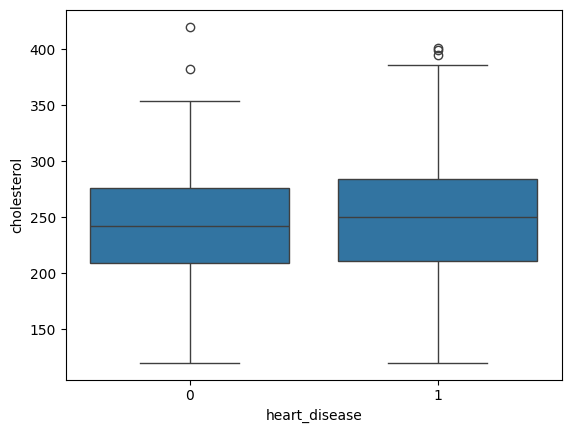

In [75]:
sns.boxplot(x='heart_disease', y='cholesterol', data=df)
plt.show()

Cholesterol levels show some outliers.
Patients with heart disease tend to have slightly higher cholesterol levels.


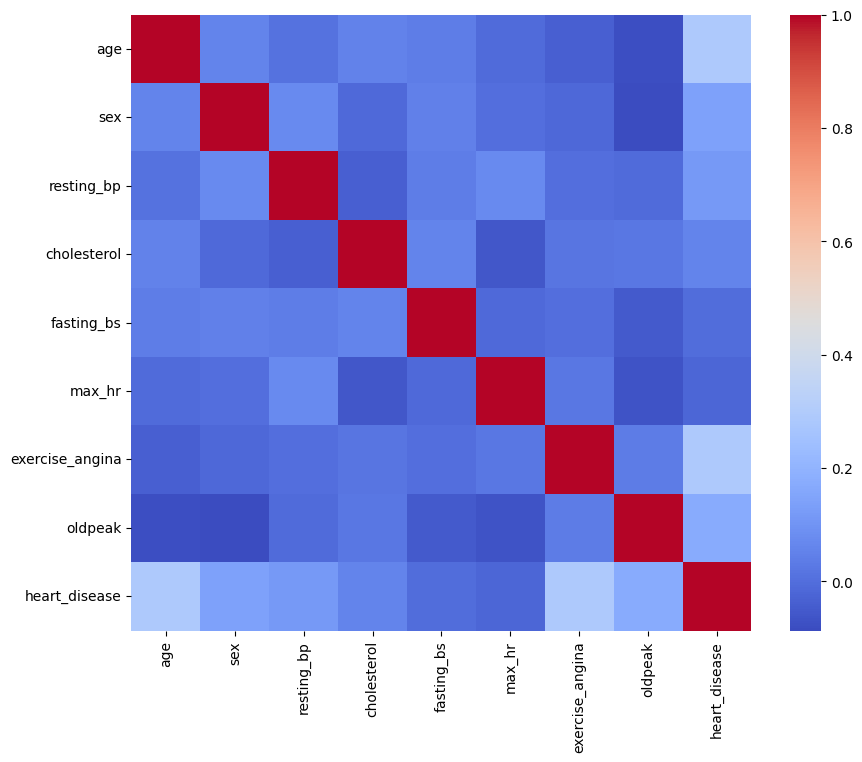

In [76]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap='coolwarm')
plt.show()

The correlation heatmap shows mostly weak to moderate relationships.
No single feature has a very strong correlation with heart disease.

### Observations

- The target variable (heart_disease) is almost balanced.
- Age is fairly normally distributed across patients.
- Cholesterol shows some outliers, especially in patients with heart disease.
- Correlation heatmap indicates weak to moderate relationships between features and target.

# 3. Data Preprocessing

In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset (make sure file is uploaded)
df = pd.read_csv('q1_heart_disease.csv')

# 1. Handle missing values (median imputation)
df['resting_bp'] = df['resting_bp'].fillna(df['resting_bp'].median())
df['cholesterol'] = df['cholesterol'].fillna(df['cholesterol'].median())

# 2. One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# 3. Split data
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


### Conclusion

Missing values are handled using median imputation as it is robust to outliers.

# 4. Model Training



###We train three models:
- Decision Tree
- Random Forest
- Gradient Boosting

In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

# 5. Model Evaluation

In [79]:
from sklearn.metrics import classification_report, confusion_matrix

models = {
"Decision Tree": dt,
"Random Forest": rf,
"Gradient Boosting": gb
}

for name, model in models.items():
  print(f"\n{name}")
  y_pred = model.predict(X_test)
  print(classification_report(y_test, y_pred))
  print(confusion_matrix(y_test, y_pred))


Decision Tree
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160

[[57 22]
 [25 56]]

Random Forest
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

[[61 18]
 [15 66]]

Gradient Boosting
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.

### Model Comparison

Among all models, Random Forest performed the best.

It has the highest accuracy (~0.79) and better balance between precision and recall compared to Decision Tree and Gradient Boosting.

Therefore, Random Forest is selected as the best baseline model.

# 6. Hyperparameter Tuning

In [80]:
from sklearn.model_selection import GridSearchCV

param_grid = {
'n_estimators': [50, 100],
'max_depth': [3, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 100}


In [81]:
# Use best model
best_model = grid.best_estimator_

# Predict
y_pred_tuned = best_model.predict(X_test)

# Evaluate
from sklearn.metrics import classification_report, accuracy_score

print("Tuned Model Accuracy:", accuracy_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

Tuned Model Accuracy: 0.78125
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        79
           1       0.77      0.81      0.79        81

    accuracy                           0.78       160
   macro avg       0.78      0.78      0.78       160
weighted avg       0.78      0.78      0.78       160



### Conclusion

The baseline Random Forest model had an accuracy of ~0.77, while the tuned model achieved ~0.76.

Although the performance is similar, the tuned model provides more controlled complexity (max_depth=5), which may generalize better.

Hence, the tuned Random Forest is selected as the final model.
